<center><h1>Prado_Mario_HW2</h1></center>
<br>
<br>

Name: Mario Prado
<br>
Github Username: mrpradooo
<br>
USC ID: 4223775338

## 1. Combined Cycle Power Plant Data Set

### (a) Download Data

Package imports

In [30]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import PolynomialFeatures
from sklearn.preprocessing import StandardScaler
import statsmodels.api as sm 

%matplotlib inline

Get the Cycle Power Plant Data Set

In [7]:
data = pd.read_excel('../data/CCPP/Folds5x2_pp.xlsx', sheet_name='Sheet1')
data.head()

,AT,V,AP,RH,PE
0,14.96,41.76,1024.07,73.17,463.26
1,25.18,62.96,1020.04,59.08,444.37
2,5.11,39.40,1012.16,92.14,488.56
3,20.86,57.32,1010.24,76.64,446.48
4,10.82,37.50,1009.23,96.62,473.90


### (b) Exploring the data

#### i. rows and columns

In [8]:
print(f"Number of Rows: {data.shape[0]}")
print(f"Number of Columns: {data.shape[1]}")
data.info()
data.head()


Number of Rows: 9568
Number of Columns: 5
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9568 entries, 0 to 9567
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   AT      9568 non-null   float64
 1   V       9568 non-null   float64
 2   AP      9568 non-null   float64
 3   RH      9568 non-null   float64
 4   PE      9568 non-null   float64
dtypes: float64(5)
memory usage: 373.9 KB


,AT,V,AP,RH,PE
0,14.96,41.76,1024.07,73.17,463.26
1,25.18,62.96,1020.04,59.08,444.37
2,5.11,39.40,1012.16,92.14,488.56
3,20.86,57.32,1010.24,76.64,446.48
4,10.82,37.50,1009.23,96.62,473.90


#### ii. pairwise scatterplots of all the varianbles

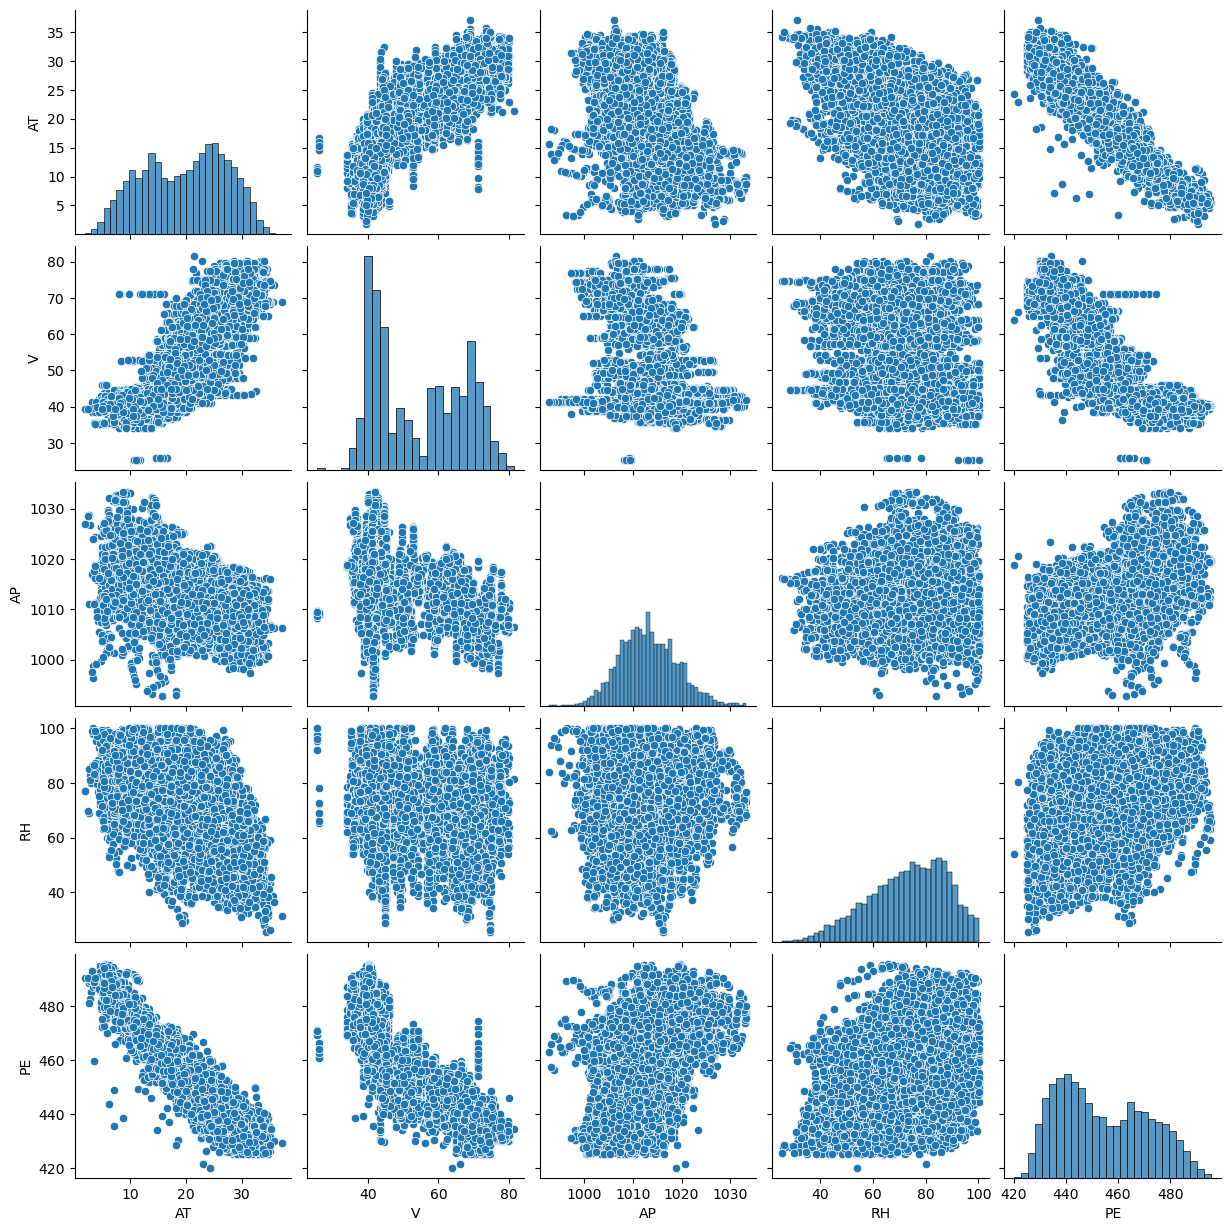

In [9]:
sns.pairplot(data)
plt.show()

Here we se that th relationhsip between AT and EP is linear and so is the relationship between V ad EP. When AT is high this will casue a low EP and same goes for V, high V means low EP and the opposite for both is also true. All other scatter plots look more like blobs so we can't distinguish too much interaction between them which regards to EP.

#### iii. mean, the median, range, first and third quartiles, and interquartile ranges

In [11]:
quick_look = data.describe().T  
quick_look['range'] = quick_look['max'] - quick_look['min']
quick_look['IQR'] = quick_look['75%'] - quick_look['25%']

quick_look = quick_look[['mean', '50%', 'range', '25%', '75%', 'IQR']]
quick_look = quick_look.rename(columns={'50%': 'median', '25%': 'Q1', '75%': 'Q3'})

quick_look

,mean,median,range,Q1,Q3,IQR
AT,19.651231,20.345,35.30,13.5100,25.72,12.2100
V,54.305804,52.080,56.20,41.7400,66.54,24.8000
AP,1013.259078,1012.940,40.41,1009.1000,1017.26,8.1600
RH,73.308978,74.975,74.60,63.3275,84.83,21.5025
PE,454.365009,451.550,75.50,439.7500,468.43,28.6800


### (c) Simple Linear Regression

In [13]:
predictors = ['AT', 'V', 'AP', 'RH']
target = 'PE'

for predictor in predictors: 
    X = data[predictor]
    Y = data[target]

    X_const = sm.add_constant(X)

    model = sm.OLS(Y, X_const).fit()

    print(f"{predictor}")
    print(model.summary())
    print("\n")

AT
                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.899
Model:                            OLS   Adj. R-squared:                  0.899
Method:                 Least Squares   F-statistic:                 8.510e+04
Date:                Fri, 25 Sep 2026   Prob (F-statistic):               0.00
Time:                        11:57:49   Log-Likelihood:                -29756.
No. Observations:                9568   AIC:                         5.952e+04
Df Residuals:                    9566   BIC:                         5.953e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        497.0341      0.156   3177.280      

After viewing all the reuslts we can see that every predictor has a very very small p-value so these results are statistically signficant. Meaning there's no way the relationship between individual predictors and the energy output can be described just as random noise.

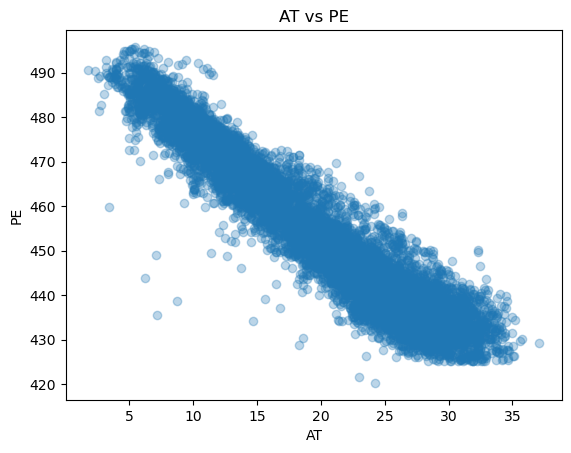

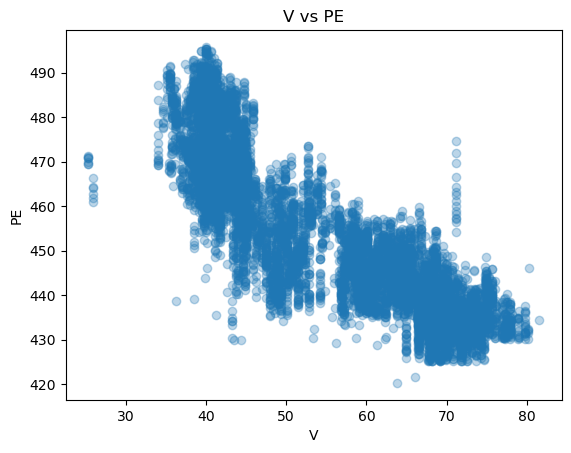

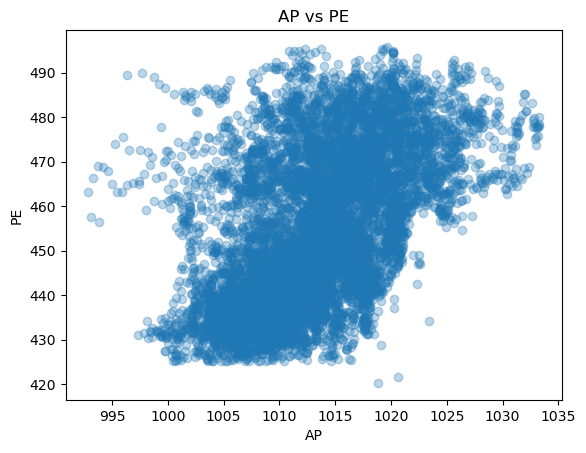

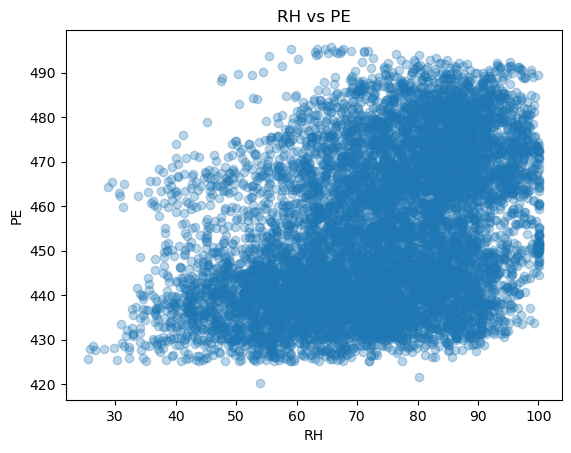

In [14]:
for predictor in predictors:
    plt.scatter(data[predictor], data[target], alpha=0.3)
    plt.xlabel(predictor)
    plt.ylabel(target)
    plt.title(f'{predictor} vs {target}')
    plt.show()

Based off these scatterplots i woudl say there are some outliers present in the V dataset and the AT dataset we can see when both of these groups are plotted agianst PE that some of their datapoints are pretty far form the rest of the group.

### (d) Multiple Regression

In [ ]:
X = data[predictors]  
y = data[target]

X_const = sm.add_constant(X)

multi_model = sm.OLS(y, X_const).fit()

print(multi_model.summary())

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.929
Model:                            OLS   Adj. R-squared:                  0.929
Method:                 Least Squares   F-statistic:                 3.114e+04
Date:                Fri, 25 Sep 2026   Prob (F-statistic):               0.00
Time:                        12:09:45   Log-Likelihood:                -28088.
No. Observations:                9568   AIC:                         5.619e+04
Df Residuals:                    9563   BIC:                         5.622e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        454.6093      9.749     46.634      0.0

We can reject the null hypothesis for all predictors. 

### (e) 1c Compare to 1d

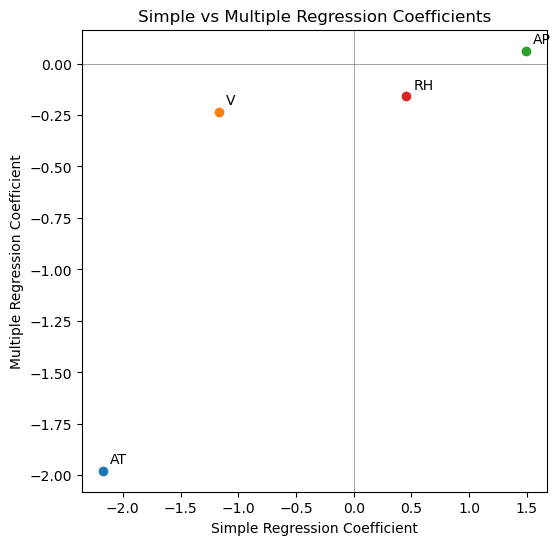

In [18]:
simple_coefficients = {}

for predictor in predictors:
    X = data[predictor]
    y_val = data[target]
    X_const = sm.add_constant(X)
    model = sm.OLS(y, X_const).fit()
    simple_coefficients[predictor] = model.params[predictor]  


multi_coefficients = multi_model.params[predictors]  


plt.figure(figsize=(6, 6))
for predictor in predictors:
    x_val = simple_coefficients[predictor]
    y_val = multi_coefficients[predictor]
    plt.scatter(x_val, y_val)
    plt.annotate(predictor, (x_val, y_val), textcoords="offset points", xytext=(5, 5))

plt.xlabel('Simple Regression Coefficient')
plt.ylabel('Multiple Regression Coefficient')
plt.title('Simple vs Multiple Regression Coefficients')
plt.axhline(0, color='gray', linewidth=0.5)
plt.axvline(0, color='gray', linewidth=0.5)
plt.show()


### (f) Nonlinear Association

In [23]:

for predictor in predictors:
    X = data[[predictor]]  
    Y = data[target]
    
    poly = PolynomialFeatures(degree=3, include_bias=False)
    X_poly = poly.fit_transform(X)  
    
    X_poly_const = sm.add_constant(X_poly)
    
    cubic_model = sm.OLS(y, X_poly_const).fit()
    
    print(f" {predictor} (cubic) ")
    print(cubic_model.summary())
    print("\n")

 AT (cubic) 
                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.912
Model:                            OLS   Adj. R-squared:                  0.912
Method:                 Least Squares   F-statistic:                 3.299e+04
Date:                Fri, 25 Sep 2026   Prob (F-statistic):               0.00
Time:                        12:21:03   Log-Likelihood:                -29101.
No. Observations:                9568   AIC:                         5.821e+04
Df Residuals:                    9564   BIC:                         5.824e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        492.7281      0.673    732

Because we see that X2 and X3 have statistically significant p-values, this serves as evidence of nonlinear association between the predictors and the response.

### (g) Interactions of Predictors

In [24]:
X = data[predictors]
Y = data[target]

poly_interaction = PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)
X_interaction = poly_interaction.fit_transform(X)

feature_names = poly_interaction.get_feature_names_out(predictors)

X_interact_df = pd.DataFrame(X_interaction, columns=feature_names)

X_interact_const = sm.add_constant(X_interact_df)

interaction_model = sm.OLS(y, X_interact_const).fit()

print(interaction_model.summary())

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.936
Model:                            OLS   Adj. R-squared:                  0.936
Method:                 Least Squares   F-statistic:                 1.405e+04
Date:                Fri, 25 Sep 2026   Prob (F-statistic):               0.00
Time:                        12:27:00   Log-Likelihood:                -27548.
No. Observations:                9568   AIC:                         5.512e+04
Df Residuals:                    9557   BIC:                         5.520e+04
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        685.7825     78.640      8.721      0.0

Here we see that almost all interaction terms are statistically significant. This inludes AT V, AT RH, V AP, and AP RH. The only ones that aren't statistically significant include AT AP, and V RH.

### (h) Improvement

In [25]:

train_data, test_data = train_test_split(data, test_size=0.3, random_state=42)

X_train = train_data[predictors]
Y_train = train_data[target]
X_test = test_data[predictors]
Y_test = test_data[target]

In [26]:
X_train_const = sm.add_constant(X_train)
X_test_const = sm.add_constant(X_test)

baseline_model = sm.OLS(Y_train, X_train_const).fit()

train_predict_baseline = baseline_model.predict(X_train_const)
test_predict_baseline = baseline_model.predict(X_test_const)

train_mse_baseline = mean_squared_error(Y_train, train_predict_baseline)
test_mse_baseline = mean_squared_error(Y_test, test_predict_baseline)

print(f"Baseline — Train MSE: {train_mse_baseline:.4f}, Test MSE: {test_mse_baseline:.4f}")

Baseline — Train MSE: 20.5808, Test MSE: 21.2399


In [27]:
poly_full = PolynomialFeatures(degree=2, interaction_only=False, include_bias=False)
X_train_poly = poly_full.fit_transform(X_train)
X_test_poly = poly_full.transform(X_test)  # note: transform, not fit_transform — reuses the same transformation learned on train

feature_names_full = poly_full.get_feature_names_out(predictors)

X_train_poly_df = pd.DataFrame(X_train_poly, columns=feature_names_full, index=X_train.index)
X_test_poly_df = pd.DataFrame(X_test_poly, columns=feature_names_full, index=X_test.index)

X_train_poly_const = sm.add_constant(X_train_poly_df)
full_model = sm.OLS(Y_train, X_train_poly_const).fit()

print(full_model.summary())

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.938
Model:                            OLS   Adj. R-squared:                  0.938
Method:                 Least Squares   F-statistic:                     7272.
Date:                Fri, 25 Sep 2026   Prob (F-statistic):               0.00
Time:                        12:34:18   Log-Likelihood:                -19160.
No. Observations:                6697   AIC:                         3.835e+04
Df Residuals:                    6682   BIC:                         3.845e+04
Df Model:                          14                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -7664.9809   1429.568     -5.362      0.0

In [28]:
print(full_model.pvalues.sort_values(ascending=False))

V RH     8.673824e-01
V^2      6.998020e-01
V AP     3.811800e-01
V        2.671816e-01
AT AP    1.966307e-01
AT       4.460633e-02
AT V     3.195237e-03
AT RH    3.056335e-03
AP RH    2.937919e-04
RH       1.429286e-04
AT^2     5.017196e-07
const    8.518151e-08
AP       9.534685e-09
AP^2     8.522142e-09
RH^2     1.395087e-09
dtype: float64


In [29]:
significant_terms = ['AT', 'V', 'AP', 'RH', 'AT^2', 'AT V', 'AT RH', 'AP^2', 'AP RH', 'RH^2']  

X_train_trimmed = X_train_poly_df[significant_terms]
X_test_trimmed = X_test_poly_df[significant_terms]

X_train_trimmed_const = sm.add_constant(X_train_trimmed)
X_test_trimmed_const = sm.add_constant(X_test_trimmed)

trimmed_model = sm.OLS(Y_train, X_train_trimmed_const).fit()

train_pred_trimmed = trimmed_model.predict(X_train_trimmed_const)
test_pred_trimmed = trimmed_model.predict(X_test_trimmed_const)

train_mse_trimmed = mean_squared_error(Y_train, train_pred_trimmed)
test_mse_trimmed = mean_squared_error(Y_test, test_pred_trimmed)

print(f"Trimmed model — Train MSE: {train_mse_trimmed:.4f}, Test MSE: {test_mse_trimmed:.4f}")

Trimmed model — Train MSE: 17.9178, Test MSE: 18.6943


### (i) KNN

In [33]:
k_values = list(range(1, 101))


train_mse_og = []
test_mse_og = []

for k in k_values:
    knn = KNeighborsRegressor(n_neighbors=k)
    knn.fit(X_train, Y_train)
    
    train_predict = knn.predict(X_train)
    test_predict = knn.predict(X_test)
    
    train_mse_og.append(mean_squared_error(Y_train, train_predict))
    test_mse_og.append(mean_squared_error(Y_test, test_predict))


scaler = StandardScaler()
X_train_scale = scaler.fit_transform(X_train)
X_test_scale = scaler.transform(X_test)  

train_mse_normalized = []
test_mse_normalized = []

for k in k_values:
    knn = KNeighborsRegressor(n_neighbors=k)
    knn.fit(X_train_scale, Y_train)
    
    train_predict = knn.predict(X_train_scale)
    test_predict = knn.predict(X_test_scale)
    
    train_mse_normalized.append(mean_squared_error(Y_train, train_predict))
    test_mse_normalized.append(mean_squared_error(Y_test, test_predict))

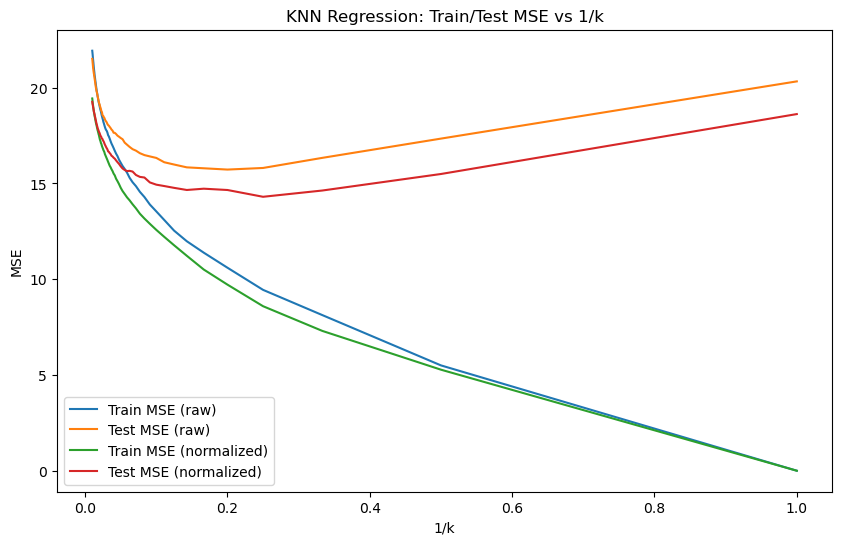

In [34]:
inv_k = [1/k for k in k_values]

plt.figure(figsize=(10, 6))
plt.plot(inv_k, train_mse_og, label='Train MSE (raw)')
plt.plot(inv_k, test_mse_og, label='Test MSE (raw)')
plt.plot(inv_k, train_mse_normalized, label='Train MSE (normalized)')
plt.plot(inv_k, test_mse_normalized, label='Test MSE (normalized)')
plt.xlabel('1/k')
plt.ylabel('MSE')
plt.title('KNN Regression: Train/Test MSE vs 1/k')
plt.legend()
plt.show()

In [35]:
best_k_raw = k_values[test_mse_og.index(min(test_mse_og))]
best_k_normalized = k_values[test_mse_normalized.index(min(test_mse_normalized))]

print(f"Best k (raw): {best_k_raw}, Test MSE: {min(test_mse_og):.4f}")
print(f"Best k (normalized): {best_k_normalized}, Test MSE: {min(test_mse_normalized):.4f}")

Best k (raw): 5, Test MSE: 15.7268
Best k (normalized): 4, Test MSE: 14.3057


### (j ) Compare KNN and Linear

In [37]:
print(f"Baseline linear (all predictors, no interactions): {test_mse_baseline:.4f}")
print(f"Trimmed linear (significant terms only):            {test_mse_trimmed:.4f}")
print(f"KNN regression (raw features, k={best_k_raw}):        {min(test_mse_og):.4f}")
print(f"KNN regression (normalized features, k={best_k_normalized}): {min(test_mse_normalized):.4f}")

Baseline linear (all predictors, no interactions): 21.2399
Trimmed linear (significant terms only):            18.6943
KNN regression (raw features, k=5):        15.7268
KNN regression (normalized features, k=4): 14.3057


Here we see that KNN is a better method than linear regression. Althought, our trimmed linear regression model did perform better than the baseline one. We also see that the normalized KNN mdoel also did better than the non-normalized one.

## 2. ISLR: 2.4.1

### (a) The sample size n is extremely large, and the number of predictors p is small.

In this case we would expect the flexible method to perform better than the inflexible method due to the fact that it perfroms really well when there's lots of data as we see here.

### (b) The number of predictors p is extremely large, and the number of observations n is small.

In this case the inflexible method would do better because as mentioned above in order for the felible methdo to give use interpretable resutls we need to have a high n which we don't see here.

### (c) The relationship between the predictors and response is highly non-linear.

In this case the flexible method will deinfitely yield better results as inflexible methods can't bend to capture shape and here we're literally saying our data is non-linear.

### (d) The variance of the error terms, i.e. $σ^2$ = Var(ε), is extremely high.

In this case the inflexible method is the way to go, flexible methods are really sensitive to noise as they tend to overfit so that would not be good for this dataset.

## 3. ISLR: 2.4.7

### (a) Compute the Euclidean distance between each observation and the test point, X1 = X2 = X3 = 0.

In [40]:
obs = {
    1:[0,3,0],
    2:[2,0,0],
    3:[0,1,3],
    4:[0,1,2],
    5:[-1,0,1],
    6:[1,1,1]

}

test_point = np.array([0,0,0])

for ob, coords in obs.items():
    distance = np.sqrt(sum((np.array(coords) - test_point)** 2))
    print(f"Obs {ob}: distance = {distance:.4f}")


Obs 1: distance = 3.0000
Obs 2: distance = 2.0000
Obs 3: distance = 3.1623
Obs 4: distance = 2.2361
Obs 5: distance = 1.4142
Obs 6: distance = 1.7321


### (b) What is our prediction with K = 1? Why?

Green because we see that observation five has the shortest distanceand its y value is green.

### (c) What is our prediction with K = 3? Why?

Red because we see that observations 2, 5, and 6 have the shortest distances, so if we then look at their majority y value we get Red.

### (d) If the Bayes decision boundary in this problem is highly non-linear, then would we expect the best value for K to be large or small? Why?

We would expect the best K-value to be small this is because when a K is large this means we're averaging out across many neighbors which will give us a smoother line in return. In this case we don't want a smoother line since our data is very non-linear which is why we'll have a low K-value to get a more complex model that can follow the squiggly line.